In [1]:
import pandas as pd
import numpy as np

In [2]:
rain_data = pd.read_csv("imdlib_rain_2024-01-01_to_2024-12-31_points.csv")
tmax_data = pd.read_csv("imdlib_tmax_2024-01-01_to_2024-12-31_points.csv")
tmin_data = pd.read_csv("imdlib_tmin_2024-01-01_to_2024-12-31_points.csv")

In [3]:
rain_data.head()

,time,"Lat: 28.5000, Lon: 77.2500"
0,2024-01-01,0.0
1,2024-01-02,0.0
2,2024-01-03,0.0
3,2024-01-04,0.0
4,2024-01-05,0.0


In [4]:
tmax_data.head()

,time,"Lat: 28.5000, Lon: 77.5000"
0,2024-01-01,15.566903
1,2024-01-02,14.120958
2,2024-01-03,15.176105
3,2024-01-04,14.038303
4,2024-01-05,13.810904


In [5]:
tmin_data.head()

,time,"Lat: 28.5000, Lon: 77.5000"
0,2024-01-01,9.214460
1,2024-01-02,7.436671
2,2024-01-03,7.174916
3,2024-01-04,6.898395
4,2024-01-05,8.559006


In [6]:
merged_df = pd.merge(tmax_data, tmin_data, on='time', how='inner')

In [7]:
merged_df = pd.merge(merged_df, rain_data, on='time', how='inner')

In [8]:
merged_df.head()

,time,"Lat: 28.5000, Lon: 77.5000_x","Lat: 28.5000, Lon: 77.5000_y","Lat: 28.5000, Lon: 77.2500"
0,2024-01-01,15.566903,9.214460,0.0
1,2024-01-02,14.120958,7.436671,0.0
2,2024-01-03,15.176105,7.174916,0.0
3,2024-01-04,14.038303,6.898395,0.0
4,2024-01-05,13.810904,8.559006,0.0


In [9]:
merged_df.rename(columns={'time': 'Date', 'Lat: 28.5000, Lon: 77.5000_x': 'tmax','Lat: 28.5000, Lon: 77.5000_y':"tmin","Lat: 28.5000, Lon: 77.2500":"rain"}, inplace=True)

In [10]:
merged_df.head()

,Date,tmax,tmin,rain
0,2024-01-01,15.566903,9.214460,0.0
1,2024-01-02,14.120958,7.436671,0.0
2,2024-01-03,15.176105,7.174916,0.0
3,2024-01-04,14.038303,6.898395,0.0
4,2024-01-05,13.810904,8.559006,0.0


In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    366 non-null    object 
 1   tmax    366 non-null    float64
 2   tmin    366 non-null    float64
 3   rain    366 non-null    float64
dtypes: float64(3), object(1)
memory usage: 11.6+ KB


In [12]:
merged_df['rain'] = merged_df['rain'].astype(int)

In [13]:
merged_df.head()

,Date,tmax,tmin,rain
0,2024-01-01,15.566903,9.214460,0
1,2024-01-02,14.120958,7.436671,0
2,2024-01-03,15.176105,7.174916,0
3,2024-01-04,14.038303,6.898395,0
4,2024-01-05,13.810904,8.559006,0


In [14]:
import pandas as pd
import numpy as np

# Saturation vapor pressure (in hPa)
def saturation_vapor_pressure(T):
    return 6.11 * 10 ** ((7.5 * T) / (237.3 + T))

# Estimate relative humidity assuming Tmin ≈ dew point
def estimate_relative_humidity(Tmax, Tmin):
    T_avg = (Tmax + Tmin) / 2
    e_T = saturation_vapor_pressure(T_avg)
    e_Td = saturation_vapor_pressure(Tmin)
    RH = 100 * (e_Td / e_T)
    return RH


In [15]:
merged_df['Humidity'] = merged_df.apply(lambda row: estimate_relative_humidity(row['tmax'], row['tmin']), axis=1)

In [16]:
merged_df.head()

,Date,tmax,tmin,rain,Humidity
0,2024-01-01,15.566903,9.214460,0,80.939673
1,2024-01-02,14.120958,7.436671,0,79.804886
2,2024-01-03,15.176105,7.174916,0,76.346605
3,2024-01-04,14.038303,6.898395,0,78.521653
4,2024-01-05,13.810904,8.559006,0,83.849489


In [17]:
merged_df.head()

,Date,tmax,tmin,rain,Humidity
0,2024-01-01,15.566903,9.214460,0,80.939673
1,2024-01-02,14.120958,7.436671,0,79.804886
2,2024-01-03,15.176105,7.174916,0,76.346605
3,2024-01-04,14.038303,6.898395,0,78.521653
4,2024-01-05,13.810904,8.559006,0,83.849489


In [18]:
import pandas as pd
import numpy as np


def saturation_vapor_pressure(T):
    return 6.11 * 10 ** ((7.5 * T) / (237.3 + T))

def calculate_pressure(Tmax, Tmin, RH):
    T_avg = (Tmax + Tmin) / 2
    e_T = saturation_vapor_pressure(T_avg) 
   
    e_actual = (RH / 100) * e_T

    P_dry = 1013  
    P_total = P_dry + e_actual
    return P_total



merged_df['Pressure'] = merged_df.apply(lambda row: calculate_pressure(row['tmax'], row['tmin'], row['Humidity']), axis=1)


print(merged_df.head())

         Date       tmax      tmin  rain   Humidity     Pressure
0  2024-01-01  15.566903  9.214460     0  80.939673  1024.651547
1  2024-01-02  14.120958  7.436671     0  79.804886  1023.326172
2  2024-01-03  15.176105  7.174916     0  76.346605  1023.142692
3  2024-01-04  14.038303  6.898395     0  78.521653  1022.951986
4  2024-01-05  13.810904  8.559006     0  83.849489  1024.146439


In [19]:
merged_df.head()

,Date,tmax,tmin,rain,Humidity,Pressure
0,2024-01-01,15.566903,9.214460,0,80.939673,1024.651547
1,2024-01-02,14.120958,7.436671,0,79.804886,1023.326172
2,2024-01-03,15.176105,7.174916,0,76.346605,1023.142692
3,2024-01-04,14.038303,6.898395,0,78.521653,1022.951986
4,2024-01-05,13.810904,8.559006,0,83.849489,1024.146439


In [20]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      366 non-null    object 
 1   tmax      366 non-null    float64
 2   tmin      366 non-null    float64
 3   rain      366 non-null    int64  
 4   Humidity  366 non-null    float64
 5   Pressure  366 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 17.3+ KB


In [21]:
df_desc = merged_df.describe()

In [22]:
print(df_desc)

             tmax        tmin        rain    Humidity     Pressure
count  366.000000  366.000000  366.000000  366.000000   366.000000
mean    31.511383   19.103019    1.655738   68.967618  1037.360050
std      7.859349    7.840267    6.296471    8.738928    10.569757
min     12.888017    4.239633    0.000000   53.121148  1021.273423
25%     26.460382   11.464467    0.000000   61.292046  1026.542036
50%     33.545368   20.461136    0.000000   67.441825  1037.065388
75%     36.538866   26.104320    0.000000   77.137426  1046.831270
max     46.898605   31.780947   75.000000   90.942326  1059.974323


In [23]:
missing_data = merged_df.isnull().sum()
print(f"Missing values in each column:\n{missing_data}")

Missing values in each column:
Date        0
tmax        0
tmin        0
rain        0
Humidity    0
Pressure    0
dtype: int64


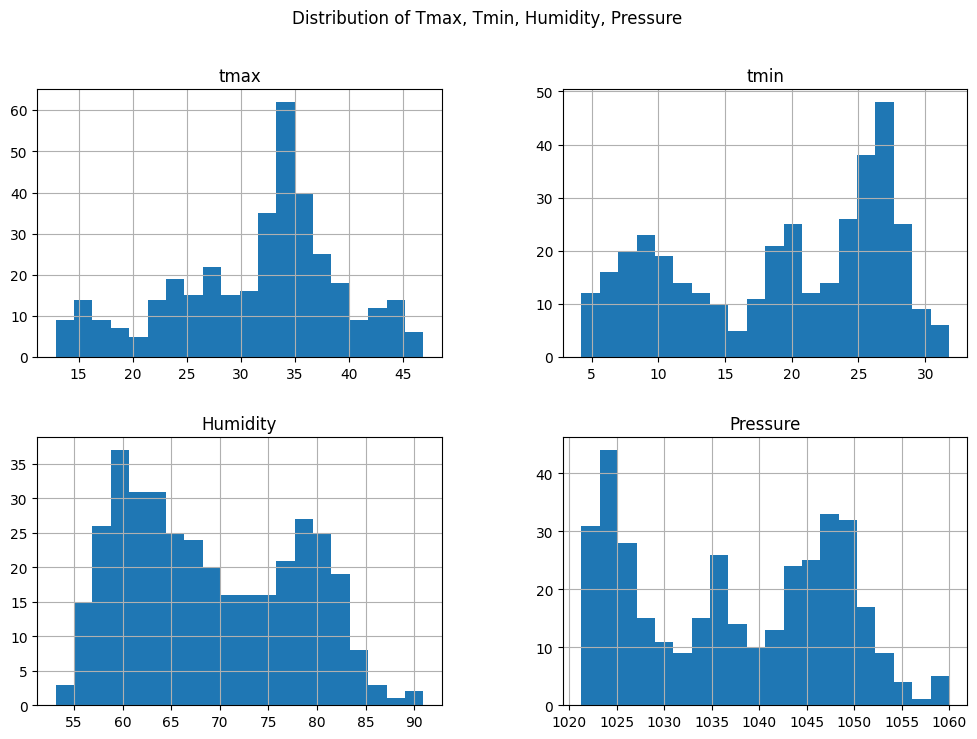

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_df[['tmax', 'tmin', 'Humidity', 'Pressure']].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribution of Tmax, Tmin, Humidity, Pressure')
plt.show()

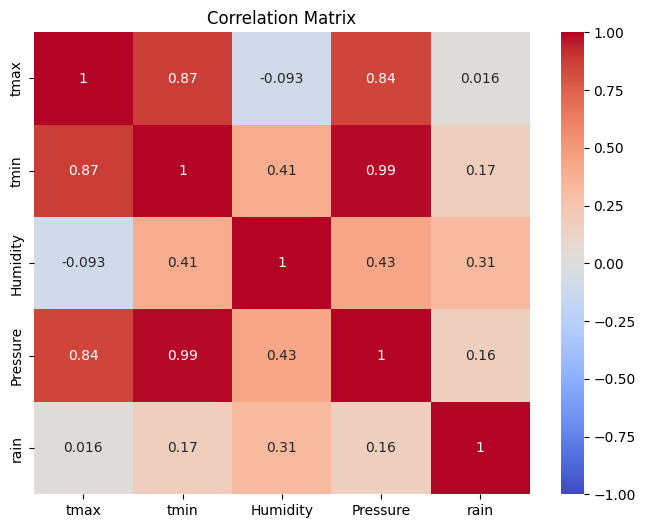

In [25]:

corr_matrix = merged_df[['tmax', 'tmin', 'Humidity', 'Pressure', 'rain']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


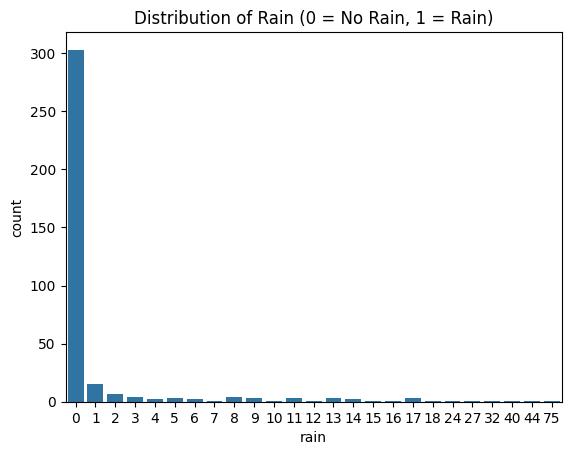

In [26]:
sns.countplot(x='rain', data=merged_df)
plt.title('Distribution of Rain (0 = No Rain, 1 = Rain)')
plt.show()

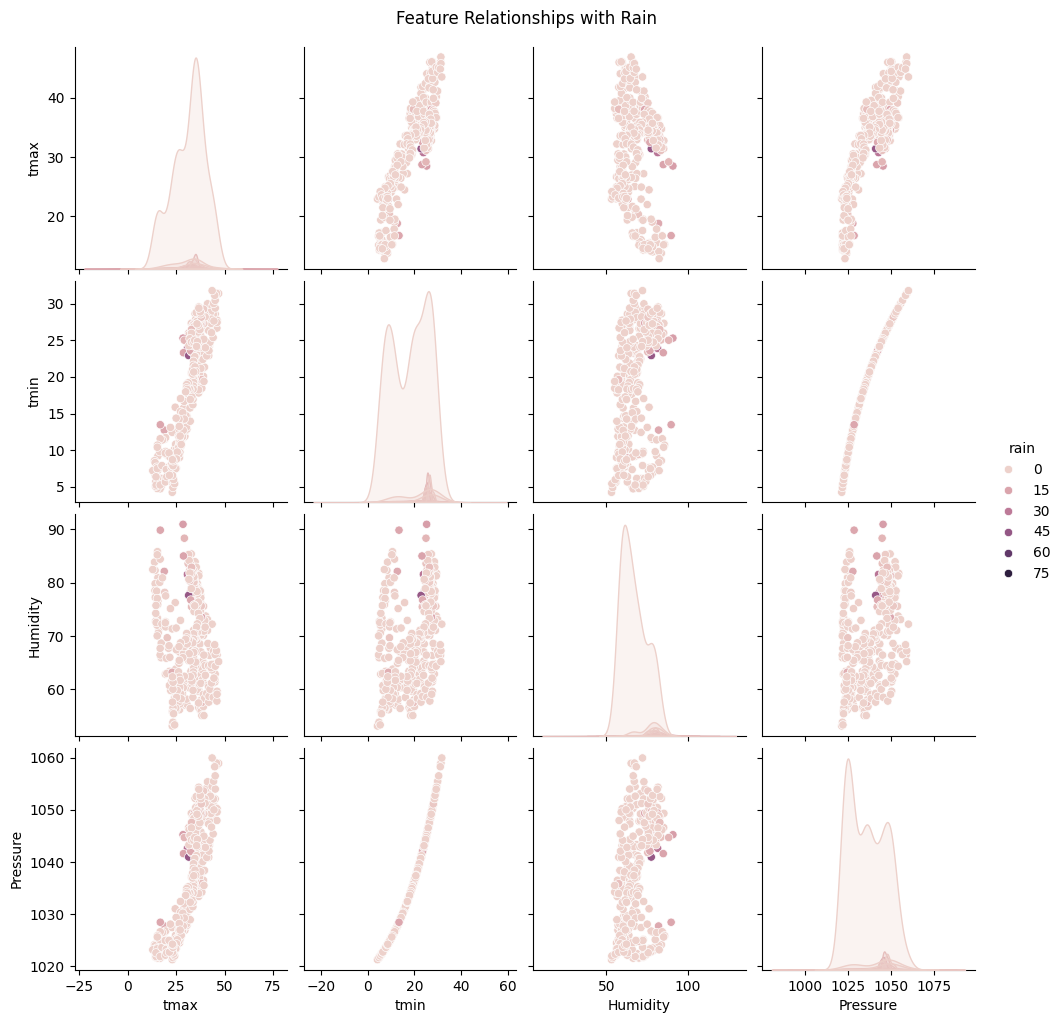

In [27]:
sns.pairplot(merged_df, hue='rain', vars=['tmax', 'tmin', 'Humidity', 'Pressure'])
plt.suptitle('Feature Relationships with Rain', y=1.02)
plt.show()

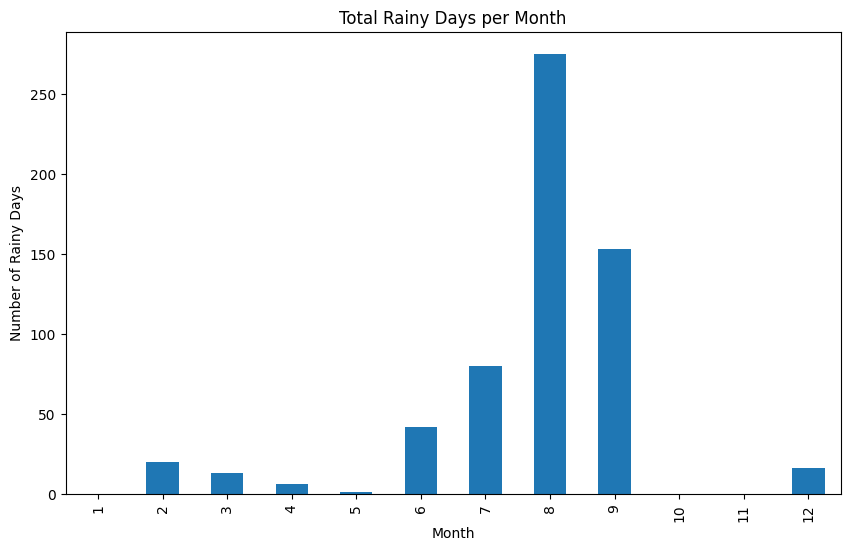

In [28]:

merged_df['Date'] = pd.to_datetime(merged_df['Date'], errors='coerce')


merged_df['Month'] = merged_df['Date'].dt.month
monthly_rain = merged_df.groupby('Month')['rain'].sum()

plt.figure(figsize=(10, 6))
monthly_rain.plot(kind='bar')
plt.title('Total Rainy Days per Month')
plt.xlabel('Month')
plt.ylabel('Number of Rainy Days')
plt.show()

In [29]:
merged_df['TempRange'] = merged_df['tmax'] - merged_df['tmin']

In [30]:
X = merged_df[['tmax', 'tmin', 'Humidity', 'Pressure', 'TempRange']]
y = merged_df['rain']

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [33]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [34]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [35]:
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of Accuracy: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.7972973  0.83561644 0.67123288 0.52054795 0.80821918]
Mean Accuracy: 0.7266
Standard Deviation of Accuracy: 0.1175


In [36]:
tmax = 32
tmin = 24
humidity = 80
pressure = 1010
temp_range = tmax - tmin

# Create feature array
tomorrow_features = np.array([[tmax, tmin, humidity, pressure, temp_range]])

# Scale the features using the same scaler used on training data
tomorrow_scaled = scaler.transform(tomorrow_features)
model.fit(X_scaled, y)  

# Predict using the trained model
prediction = model.predict(tomorrow_scaled)

# Output the result
if prediction[0] == 1:
    print("🌧️ It will RAIN tomorrow.")
else:
    print("☀️ No rain tomorrow.")

☀️ No rain tomorrow.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
import joblib

# Save the model
joblib.dump(model, 'rain_prediction_model.pkl')

# Save the scaler
joblib.dump(scaler, 'feature_scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
